This document is meant to test the discretization invariance of the 2D Fourier neural operator on a heat equation dataset.

In [35]:
from CDE_helper import *
import matplotlib.pyplot as plt
from utilities3 import MatReader
from FNO2D_def import *
import os
import torch.nn.functional as F

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")


In [ ]:
#Load model: navier stokes

modes1 = modes2 = 16
width = 128
model_path = "/scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_showcase.pt"
highres_path = "/scratch/mnhagen/datasets/navier_stokes/navier_stokes2D_autoreg_N128_nu1e-05_samples1000_dt0.005_store1000_forced0.5_filter16.h5"
resolutions = [32, 64, 128] 

dataset = "navier_stokes"

In [48]:
#Load model: heat2d

modes1 = modes2 = 16
width = 128
model_path = "/scratch/mnhagen/models/heat2d/FNO2D_heat2d_k16_w128_N128_sub2.pt"
highres_path = "/scratch/mnhagen/datasets/heat2d/heat2D_autoreg_N128_nu0.001_samples1000_dt0.001_store1000.h5"
resolutions = [32, 64, 128] 

dataset = "heat2d"

In [ ]:

path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_autoreg_N32_multi.h5"

test, _ = load_h5(path, dataset = "navier_stokes")

print(test.shape)

torch.Size([100, 1, 32, 32])


: 

In [49]:
model = FNO2D(modes1, modes2, width).cuda()
model.q = torch.nn.Conv2d(width, 1, 1)  # same as in your training script
model.load_state_dict(torch.load(model_path))
model = model.cuda()
model.eval()

# Load high-res dataset
omega_in, omega_out = load_h5(highres_path, dataset = dataset)
print(f"Loaded dataset '{dataset}': {omega_in.shape[0]} samples, grid {omega_in.shape[-1]}×{omega_in.shape[-1]}")

print(omega_in.shape)

myloss = LpLoss(size_average=True)

Loaded dataset 'heat2d': 1000 samples, grid 128×128
torch.Size([1000, 1, 128, 128])


In [50]:
results = []
train_N = 64  # the resolution the model was trained on
modes = 16    # number of Fourier modes used in model

for N in resolutions:
    factor = 128 // N
    mean_rel, std_rel, N_eval = evaluate_subsampled(model, omega_in, omega_out, factor,
                                                    train_N=train_N, modes=modes)
    print(f"N = {N_eval} | Rel L2 mean = {mean_rel:.4e} | std = {std_rel:.4e}")
    results.append((N_eval, mean_rel, std_rel))

means = [res[1] for res in results]


N = 32 | Rel L2 mean = 2.1259e-01 | std = 1.0559e-02
N = 64 | Rel L2 mean = 4.2661e-03 | std = 2.1546e-04
N = 128 | Rel L2 mean = 1.8389e-01 | std = 9.3007e-03


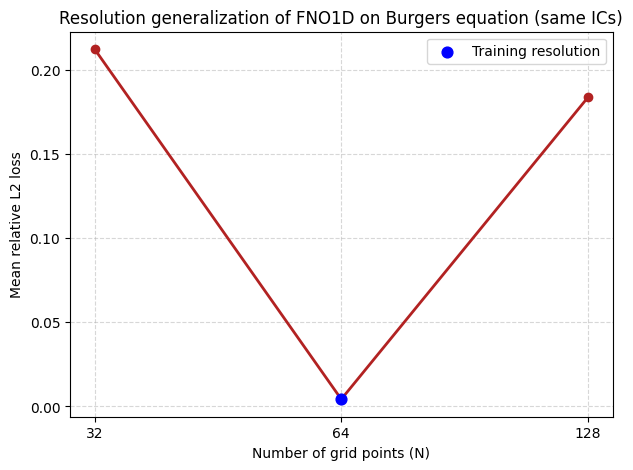

In [51]:
# Plot


plt.figure(figsize=(7,5))
plt.plot(resolutions, means, 'o-', color="firebrick", lw=2)

for i in range(len(resolutions)):
    if resolutions[i] == train_N:
        plt.scatter(resolutions[i], means[i], color='blue', s=60, zorder=5, label='Training resolution')

plt.xscale('log', base=2)
plt.xticks(resolutions, [str(r) for r in resolutions])
plt.xlabel("Number of grid points (N)")
plt.ylabel("Mean relative L2 loss")
plt.title("Resolution generalization of FNO1D on Burgers equation (same ICs)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

Thus we see that the network is not truly discretization invariant. The model performs significantly worse on resolutions different from its training resolution; predictions per resolution are plotted below.

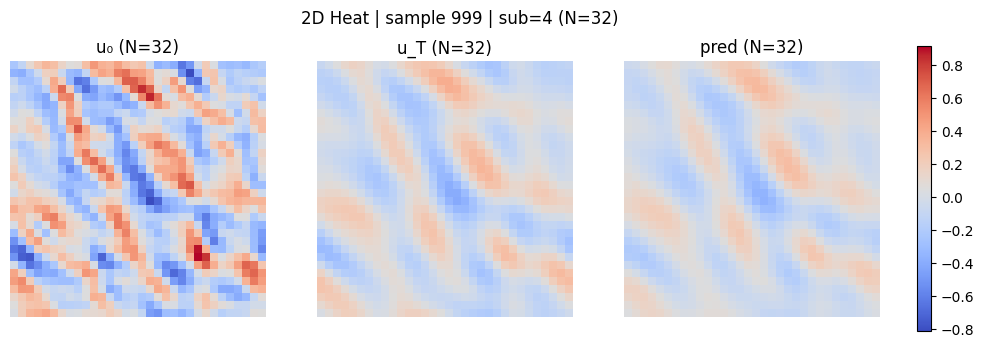

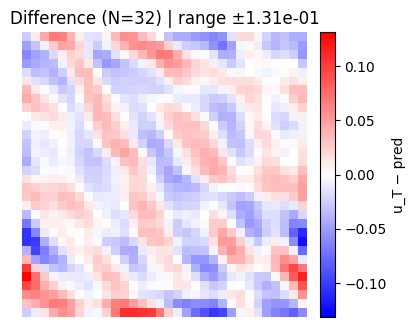

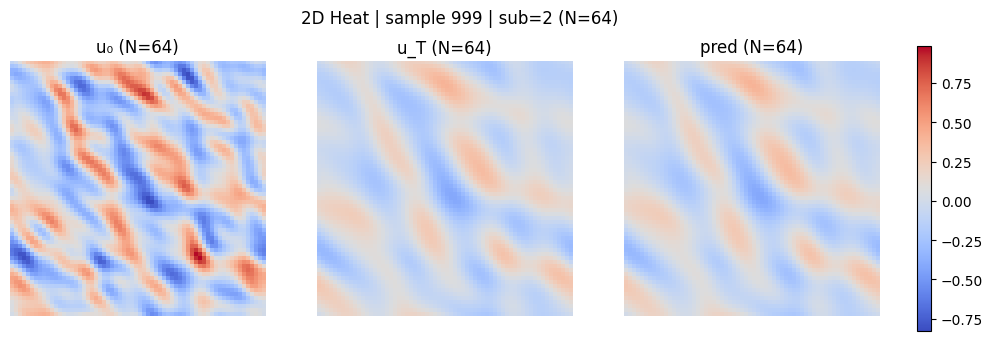

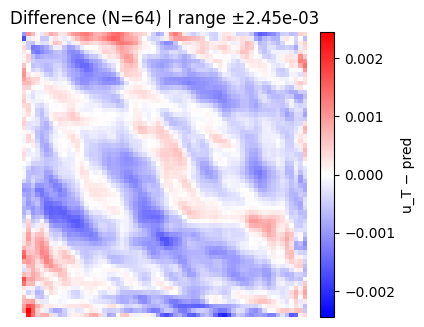

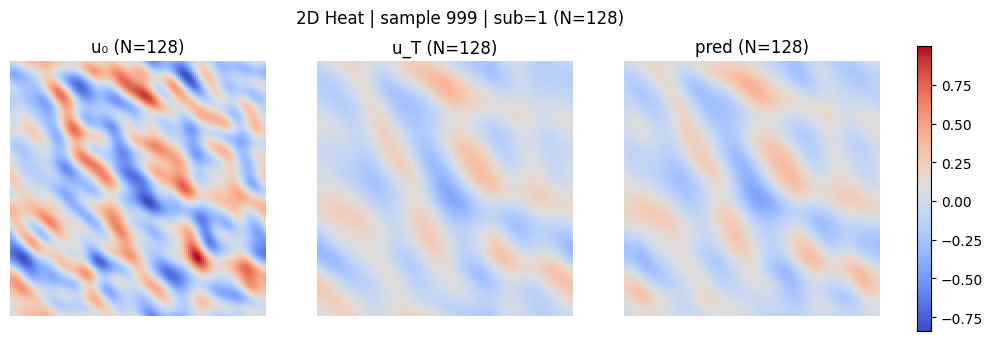

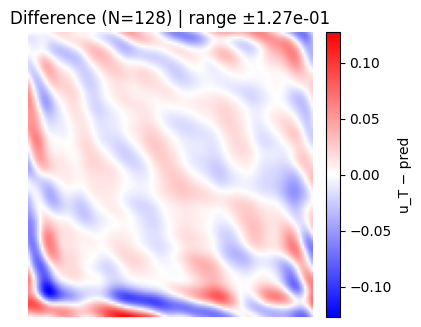

In [53]:
eval_and_plot_sample(highres_path, model, sample_idx=999, subs=(4, 2, 1),
                    train_N=64, train_modes=16, device="cuda:0", dataset=dataset)

We see in the plots above that the model still output predictions that look close to the ground truth visually on resolutions different from the training resolution, but have greater relative error. Notably, the model seems to overestimate the amplitudes everywhere, with errors up to about 15-20%. the errors at N = 32 largely come from aliasing introduced in the downsampling, and at N = 128 they largely come from lacking high frequency information. The FNO is capped at 16 modes in each direction, which is half of the possible frequencies for N = 64 but only a quarter for N = 128, introducing significant errors. To solve this, I bandlimited the initial condition and time evolution to 12 modes, lower than the FNO. the results can be seen below.

In [41]:
modes1 = modes2 = 16
width = 128
model_path_bandlimited = "/scratch/mnhagen/models/heat2d/FNO2D_heat2d_k16_w128_N128_sub2_bandlimited8.pt"
highres_path_bandlimited = "/scratch/mnhagen/datasets/heat2d/heat2D_autoreg_N128_nu0.001_samples1000_dt0.001_store1000_bandlimited8.h5"
resolutions = [32, 64, 128] 

In [42]:
model = FNO2D(modes1, modes2, width).cuda()
model.q = torch.nn.Conv2d(width, 1, 1)  # same as in your training script
model.load_state_dict(torch.load(model_path_bandlimited))
model = model.cuda()
model.eval()

# Load high-res dataset
omega_in, omega_out = load_navier_stokes_h5(highres_path_bandlimited)
print(f"Loaded dataset: {omega_in.shape[0]} samples, grid {omega_in.shape[-1]}×{omega_in.shape[-1]}")

myloss = LpLoss(size_average=True)

Loaded dataset: 1000 samples, grid 128×128


In [43]:
results = []
train_N = 64  # the resolution the model was trained on
modes = 16    # number of Fourier modes used in model

for N in resolutions:
    factor = 128 // N
    mean_rel, std_rel, N_eval = evaluate_subsampled(model, omega_in, omega_out, factor,
                                                    train_N=train_N, modes=modes)
    print(f"N = {N_eval} | Rel L2 mean = {mean_rel:.4e} | std = {std_rel:.4e}")
    results.append((N_eval, mean_rel, std_rel))

means = [res[1] for res in results]

N = 32 | Rel L2 mean = 2.7326e-01 | std = 1.2906e-02
N = 64 | Rel L2 mean = 9.0271e-03 | std = 6.5088e-04
N = 128 | Rel L2 mean = 3.1277e-01 | std = 1.5541e-02
